In [1]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import rasterio
import tifffile
import skimage
from matplotlib import pyplot as plt
from tqdm import tqdm
import cv2
import higra as hg
import torch
import pickle

In [2]:
# https://github.com/waldnerf/decode/blob/main/postprocessing/instance_segmentation.py
def watershed(input_hws, t_bound):
    # Create the directed graph
    size = input_hws.shape[:2]
    graph = hg.get_8_adjacency_graph(size)
    edge_weights = hg.weight_graph(
        graph,
        input_hws,
        hg.WeightFunction.mean)

    tree, altitudes = hg.watershed_hierarchy_by_dynamics(
        graph,
        edge_weights)
    
    # Get individual fields
    # by cutting the graph using altitude
    instances = hg.labelisation_horizontal_cut_from_threshold(
        tree,
        altitudes,
        threshold=t_bound).astype(float)
    return instances

In [3]:
# https://stackoverflow.com/questions/66595055/fastest-way-of-computing-binary-mask-iou-with-numpy
def iou(mask1, mask2):
    intersection = (mask1 * mask2).sum()
    if intersection == 0:
        return 0.0
    union = torch.logical_or(mask1, mask2).to(torch.int).sum()
    return intersection / union

In [4]:
import itertools
def compute_pair_to_iou_dict(masks):
    indices = np.arange(len(masks))
    pairs = itertools.combinations(indices, 2)
    pair_to_iou = {}
    for pair in pairs:
        i, j = pair
        pair_to_iou[tuple(pair)] = iou(masks[i], masks[j]).numpy()
    return pair_to_iou

# Finite sample algorithm

In [14]:
T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(0, 1.01, .01)])
IOU_threshold = 0.7
alpha = .2

In [15]:
file = open('../data/ftw_predictions/france_test/conformal_ious_more_T_values.pkl', 'rb')
results_table = pickle.load(file)
file.close()

In [16]:
m = int(len(results_table)/2)
results_table['calibration_step'] = 'step2'
results_table.loc[results_table.sample(n=m, random_state=0).index, 'calibration_step'] = 'step1'

In [17]:
results_table_1 = results_table[results_table['calibration_step'] == 'step1']
results_table_2 = results_table[results_table['calibration_step'] == 'step2']

In [18]:
print(len(results_table_1))
print(len(results_table_2))

1238
1238


Step 1

In [20]:
import itertools
import math

T_ordering_indices = []
IOUs = np.array([np.array(x) for x in results_table_1["IOUs"]])
IOUs_high = (IOUs>IOU_threshold).astype(int)
while True:
    coverage_by_T = IOUs_high.sum(axis=0)
    if np.max(coverage_by_T) == 0:
        break
    else:
        best_T = np.argmax(coverage_by_T)
        calibration_pixels_covered = np.argwhere(IOUs_high[:, best_T]==1)
        IOUs_high = np.delete(IOUs_high, calibration_pixels_covered, axis=0)
        T_ordering_indices.append(int(best_T))

T_ordering = T_values[T_ordering_indices]
print("T indices in ranked order from highest to lowest priority:", T_ordering_indices)
print("T in ranked order from highest to lowest priority:", T_ordering)

T indices in ranked order from highest to lowest priority: [33, 0, 67, 15, 44, 79, 3, 20, 10, 38, 45, 53, 82, 86]
T in ranked order from highest to lowest priority: [0.24  0.001 0.58  0.06  0.35  0.7   0.004 0.11  0.01  0.29  0.36  0.44
 0.73  0.77 ]


Step 2

In [27]:
pair_to_iou_dicts = []
for index, row in tqdm(results_table_2.iterrows(), total=results_table_2.shape[0]):
    image_number = row["image_number"]
    coord = row["coord"]
    pred_probability = rasterio.open(os.path.join('../data/ftw_predictions/france_test/predictions_3class/probability', image_number+'.tif')).read()[2]
    pred_shapes_coord = []

    size = pred_probability.shape[:2]
    graph = hg.get_8_adjacency_graph(size)
    edge_weights = hg.weight_graph(
        graph,
        pred_probability,
        hg.WeightFunction.mean)
    tree, altitudes = hg.watershed_hierarchy_by_dynamics(
        graph,
        edge_weights)
    
    for T in T_ordering[:8]:
        pred_segmentation = hg.labelisation_horizontal_cut_from_threshold(tree,altitudes,threshold=T).astype(float)
        pred_field = pred_segmentation==pred_segmentation[coord]
        pred_shapes_coord.append(torch.from_numpy(pred_field))
    pair_to_iou_dicts.append(compute_pair_to_iou_dict(pred_shapes_coord))

results_table_2["Pred Mask Pair to IOUs"] = pair_to_iou_dicts

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1238/1238 [02:22<00:00,  8.71it/s]
/tmp/ipykernel_456/4266054615.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_2["Pred Mask Pair to IOUs"] = pair_to_iou_dicts


In [62]:
def remove_duplicate_masks_finite_sample(indices, pair_to_iou, iou_threshold):
    if len(indices) == 1:
        return indices
    else:
        indices_to_keep = remove_duplicate_masks_finite_sample(indices[:-1], pair_to_iou, iou_threshold)
        for index in indices[:-1]:
            IOU = pair_to_iou[(index, indices[-1])]
            if IOU > iou_threshold:
                return indices_to_keep
        indices_to_keep.append(indices[-1])
        return indices_to_keep

In [63]:
IOU_threshold_duplicate_mask = 0.9
n2 = len(results_table_2)
pair_to_iou_dicts = np.array(results_table_2["Pred Mask Pair to IOUs"])
IOUs = np.array([np.array(x) for x in results_table_2["IOUs"]])
IOUs_high = (IOUs>IOU_threshold).astype(int)[:, T_ordering_indices]
target_risk = alpha - (1-alpha)/n2

for i in range(len(T_ordering_indices)):
    num_points_covered = 0
    for j in range(n2):
        pair_to_iou = pair_to_iou_dicts[j]
        indices_to_keep = remove_duplicate_masks_finite_sample(list(np.arange(i+1)), pair_to_iou, IOU_threshold_duplicate_mask)
        if np.max(IOUs_high[j][indices_to_keep]) == 1:
            num_points_covered += 1
    risk = 1 - num_points_covered / n2 # fraction of points that have not been covered
    if risk <= target_risk:
        break

T_confidence_set_indices = T_ordering_indices[:i+1]
T_confidence_set = T_values[T_confidence_set_indices]

print("target risk:", target_risk)
print("final risk:", risk)
if risk > target_risk:
    print("alpha too small")
else:
    print("T confidence set indices:", T_confidence_set_indices)
    print("T confidence set:", T_confidence_set)

target risk: 0.19935379644588047
final risk: 0.19547657512116312
T confidence set indices: [33, 0, 67, 15, 44, 79]
T confidence set: [0.24  0.001 0.58  0.06  0.35  0.7  ]


In [64]:
file = open('field_delineation_finite_sample_calibration_step_2.pkl', 'wb')
pickle.dump(results_table_2, file)
file.close()

In [28]:
results_table_2

,image_number,coord,IOUs,calibration_step,Pred Mask Pair to IOUs
0,g212_00063_1,"(211, 151)","[0.18637274205684662, 0.18637274205684662, 0.1...",step2,"{(0, 1): 0.70454544, (0, 2): 1.0, (0, 3): 0.70..."
3,g165_00035_5,"(177, 25)","[0.23930130898952484, 0.33322814106941223, 0.3...",step2,"{(0, 1): 0.24629486, (0, 2): 0.9664531, (0, 3)..."
7,g165_00035_5,"(242, 210)","[0.09993942826986313, 0.09463722258806229, 0.0...",step2,"{(0, 1): 0.7039488, (0, 2): 0.9888138, (0, 3):..."
8,g165_00035_5,"(219, 22)","[0.5184764266014099, 0.7749860286712646, 0.774...",step2,"{(0, 1): 0.18857254, (0, 2): 0.9664531, (0, 3)..."
12,g165_00035_5,"(184, 74)","[0.4128205180168152, 0.4128205180168152, 0.412...",step2,"{(0, 1): 0.44378698, (0, 2): 1.0, (0, 3): 1.0,..."
...,...,...,...,...,...
2465,g212_00096_16,"(181, 79)","[0.9535355567932129, 0.9535355567932129, 0.953...",step2,"{(0, 1): 0.73226357, (0, 2): 0.542061, (0, 3):..."
2470,g212_00096_16,"(36, 42)","[0.5677839517593384, 0.5675342679023743, 0.567...",step2,"{(0, 1): 0.9995603, (0, 2): 0.45793903, (0, 3)..."
2472,g212_00096_16,"(94, 60)","[0.5677839517593384, 0.5675342679023743, 0.567...",step2,"{(0, 1): 0.9995603, (0, 2): 0.45793903, (0, 3)..."
2474,g212_00096_16,"(40, 82)","[0.5677839517593384, 0.5675342679023743, 0.567...",step2,"{(0, 1): 0.9995603, (0, 2): 0.45793903, (0, 3)..."


# Find coverage on test set

In [73]:
file = open('../data/ftw_predictions/france_test/conformal_ious_test_with_pairwise_IOUs_more_T_values.pkl', 'rb')
results_table_test_asymptotic = pickle.load(file)
file.close()

In [74]:
results_table_test = results_table_test_asymptotic[['image_number', 'coord']]

In [75]:
pair_to_iou_dicts = []
IOUs = []
for index, row in tqdm(results_table_test.iterrows(), total=results_table_test.shape[0]):
    image_number = row["image_number"]
    coord = row["coord"]
    true_segmentation = rasterio.open(os.path.join('../data/ftw/france/label_masks/instance', image_number+'.tif')).read()[0]
    true_field = true_segmentation==true_segmentation[coord]
    pred_probability = rasterio.open(os.path.join('../data/ftw_predictions/france_test/predictions_3class/probability', image_number+'.tif')).read()[2]
    pred_shapes_coord = []
    IOUs_coord = []

    size = pred_probability.shape[:2]
    graph = hg.get_8_adjacency_graph(size)
    edge_weights = hg.weight_graph(
        graph,
        pred_probability,
        hg.WeightFunction.mean)
    tree, altitudes = hg.watershed_hierarchy_by_dynamics(
        graph,
        edge_weights)

    for T in T_confidence_set:
        pred_segmentation = hg.labelisation_horizontal_cut_from_threshold(tree,altitudes,threshold=T).astype(float)
        pred_field = pred_segmentation==pred_segmentation[coord]
        IOU = iou(torch.from_numpy(true_field), torch.from_numpy(pred_field))
        pred_shapes_coord.append(torch.from_numpy(pred_field))
        IOUs_coord.append(IOU)
    
    pair_to_iou_dicts.append(compute_pair_to_iou_dict(pred_shapes_coord))
    IOUs.append(IOUs_coord)

results_table_test["Pred Mask Pair to IOUs"] = pair_to_iou_dicts
results_table_test["IOUs"] = IOUs

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [02:33<00:00,  5.99it/s]
/tmp/ipykernel_456/2073101569.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_test["Pred Mask Pair to IOUs"] = pair_to_iou_dicts
/tmp/ipykernel_456/2073101569.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_test["IOUs"] = IOUs


In [78]:
results_table_test["Final Mask Indices"] = results_table_test["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_finite_sample(list(np.arange(len(T_confidence_set))), x, iou_threshold=IOU_threshold_duplicate_mask))
results_table_test["Final Mask Number"] = results_table_test["Final Mask Indices"].apply(lambda x: len(x))
results_table_test["Final Mask IOUs"] = results_table_test.apply(lambda x: np.array(x["IOUs"])[x["Final Mask Indices"]], axis=1)
results_table_test["Final Mask max IOU"] = results_table_test["Final Mask IOUs"].map(lambda x: np.max(x))

In [79]:
results_table_test

,image_number,coord,Pred Mask Pair to IOUs,IOUs,Final Mask Indices,Final Mask Number,Final Mask IOUs,Final Mask max IOU
0,g165_00003_0,"(67, 127)","{(0, 1): 1.0, (0, 2): 1.0, (0, 3): 1.0, (0, 4)...","[tensor(0.8354), tensor(0.8354), tensor(0.8354...","[0, 5]",2,"[0.835443, 0.27583587]",0.835443
1,g165_00003_0,"(103, 202)","{(0, 1): 1.0, (0, 2): 1.0, (0, 3): 1.0, (0, 4)...","[tensor(0.7165), tensor(0.7165), tensor(0.7165...","[0, 5]",2,"[0.7164686, 0.16033435]",0.716469
2,g165_00003_0,"(21, 163)","{(0, 1): 0.07305936, (0, 2): 0.49103138, (0, 3...","[tensor(0.7523), tensor(0.0794), tensor(0.3697...","[0, 1, 2, 3, 5]",5,"[0.75227964, 0.07936508, 0.36967885, 0.5756014...",0.752280
3,g165_00003_0,"(87, 114)","{(0, 1): 0.9918367, (0, 2): 1.0, (0, 3): 1.0, ...","[tensor(0.8513), tensor(0.8577), tensor(0.8513...","[0, 5]",2,"[0.85130113, 0.09108565]",0.851301
4,g165_00003_0,"(70, 183)","{(0, 1): 0.4939551, (0, 2): 0.24690832, (0, 3)...","[tensor(0.2524), tensor(0.1233), tensor(0.9391...","[0, 1, 2, 4, 5]",5,"[0.25235742, 0.12331233, 0.93912303, 0.5763981...",0.939123
...,...,...,...,...,...,...,...,...
912,g212_00037_6,"(161, 131)","{(0, 1): 0.62302005, (0, 2): 0.44480976, (0, 3...","[tensor(0.8583), tensor(0.5573), tensor(0.3831...","[0, 1, 2, 5]",4,"[0.85834205, 0.55726874, 0.38313818, 0.019605493]",0.858342
913,g212_00037_6,"(117, 86)","{(0, 1): 1.0, (0, 2): 1.0, (0, 3): 1.0, (0, 4)...","[tensor(0.9333), tensor(0.9333), tensor(0.9333...","[0, 5]",2,"[0.9332781, 0.10969149]",0.933278
914,g212_00037_6,"(106, 129)","{(0, 1): 0.53919697, (0, 2): 0.6426816, (0, 3)...","[tensor(0.5371), tensor(0.9503), tensor(0.3459...","[0, 1, 2, 5]",4,"[0.53708005, 0.9503438, 0.34585035, 0.06155764]",0.950344
915,g212_00037_6,"(200, 155)","{(0, 1): 0.14555256, (0, 2): 0.31617522, (0, 3...","[tensor(0.9462), tensor(0.1415), tensor(0.2996...","[0, 1, 2, 5]",4,"[0.94620764, 0.14149354, 0.29960823, 0.04226095]",0.946208


In [80]:
results_table_test_high_IOUs = results_table_test[results_table_test["Final Mask max IOU"] > IOU_threshold]
coverage = len(results_table_test_high_IOUs) / len(results_table_test)
print(coverage)

0.7786259541984732


In [82]:
file = open('field_delineation_finite_sample_test.pkl', 'wb')
pickle.dump(results_table_test, file)
file.close()

# Visualize confidence set size histogram

In [87]:
IOU_threshold_duplicate_mask = 0.9

In [88]:
# Load results from asymptotic version

def remove_duplicate_masks_asymptotic(indices, pair_to_iou, iou_threshold=0.95):
    for k in np.arange(1, len(indices)+1):
        for new_indices in itertools.combinations(indices, k):
            removed_indices = list(set(indices) - set(new_indices))
            valid_combination = True
            for i in removed_indices:
                new_indices_contain_similar_mask = False
                for j in new_indices:
                    if pair_to_iou[tuple(sorted((i, j)))] > iou_threshold:
                        new_indices_contain_similar_mask = True
                        break
                if not new_indices_contain_similar_mask:
                    valid_combination = False
                    break
            if valid_combination:
                return list(new_indices)

file = open('../data/ftw_predictions/france_test/conformal_ious_test_with_pairwise_IOUs_more_T_values.pkl', 'rb')
results_table_test = pickle.load(file)
file.close()

T_confidence_set = np.array([0.001, 0.003, 0.12,  0.31,  0.58 ])
indices = np.arange(len(T_confidence_set))
results_table_test["Final Mask Indices"] = results_table_test["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_asymptotic(indices, x, iou_threshold=IOU_threshold_duplicate_mask))
results_table_test["Final Mask Number"] = results_table_test["Final Mask Indices"].apply(lambda x: len(x))

In [90]:
# Load results from finite sample version

file = open('field_delineation_finite_sample_test.pkl', 'rb')
results_table_test_finite_sample = pickle.load(file)
file.close()

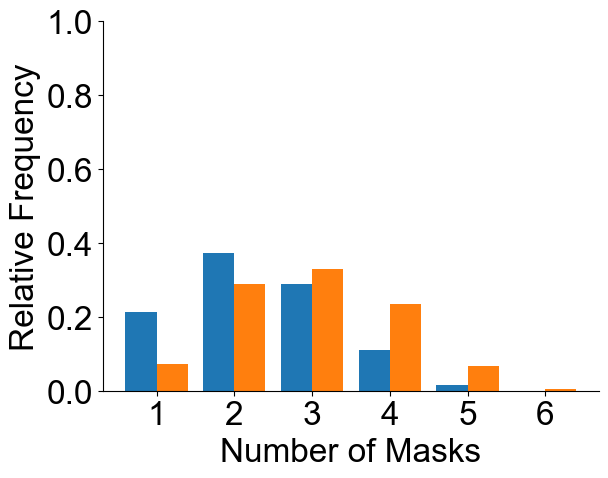

In [98]:
plt.rcParams["font.sans-serif"] = "Arial"

plt.rc('font', size=24)          
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)    
plt.rc('xtick', labelsize=24)    
plt.rc('ytick', labelsize=24)    
plt.rc('figure', titlesize=24)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

width = 0.4
plt.bar(results_table_test['Final Mask Number'].value_counts().index - width/2, results_table_test['Final Mask Number'].value_counts().values/len(results_table_test), width, label='asymptotic')
plt.bar(results_table_test_finite_sample['Final Mask Number'].value_counts().index + width/2, results_table_test_finite_sample['Final Mask Number'].value_counts().values/len(results_table_test_finite_sample), width, label='finite sample')
plt.xticks(np.arange(1, 7))
plt.ylim([0, 1])
plt.xlabel("Number of Masks")
plt.ylabel("Relative Frequency")
#plt.legend()
plt.show()